# Lab 4 — Rhythmogram and tempo path

A single autocorrelation describes one analysis window. A **rhythmogram** repeats this analysis through time, producing $R(t,\tau)$. Ridges reveal how periodicity evolves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from IPython.display import Audio, display

np.set_printoptions(precision=3, suppress=True)

def unbiased_autocorrelation(x, max_lag=None, normalize=True):
    x = np.asarray(x, dtype=float).reshape(-1)
    if max_lag is None:
        max_lag = len(x)-1
    max_lag = min(int(max_lag), len(x)-1)
    r = np.empty(max_lag+1)
    for tau in range(max_lag+1):
        a=x[:len(x)-tau]; b=x[tau:]
        r[tau] = np.dot(a,b)/max(1,len(a))
    if normalize and r[0] > 0:
        r = r/r[0]
    return r

def phase_autocorrelation(x, lags, unbiased=True):
    x=np.asarray(x,dtype=float).reshape(-1)
    lags=np.asarray(lags,dtype=int)
    P=np.zeros((len(lags), int(lags.max())))
    C=np.zeros_like(P)
    N=len(x)
    for ir,tau in enumerate(lags):
        for phi in range(tau):
            idx=np.arange(phi, N-tau, tau, dtype=int)
            if len(idx):
                P[ir,phi]=np.sum(x[idx]*x[idx+tau])
                C[ir,phi]=len(idx)
    if unbiased:
        return P/np.where(C==0,1,C), C
    return P, C

def frame_signal(x, frame_length, hop_length, center=True):
    x=np.asarray(x,float).reshape(-1)
    if center:
        p=frame_length//2
        x=np.pad(x,(p,p))
    starts=np.arange(0,max(1,len(x)-frame_length+1),hop_length,dtype=int)
    return np.stack([x[s:s+frame_length] for s in starts],axis=1), starts

def rhythmogram(x, frame_length=256, hop_length=32, lag_min=8, lag_max=96):
    frames, starts = frame_signal(x, frame_length, hop_length, center=True)
    lags=np.arange(lag_min,lag_max+1)
    R=np.zeros((len(lags),frames.shape[1]))
    w=np.hanning(frame_length)
    for j in range(frames.shape[1]):
        f=(frames[:,j]-frames[:,j].mean())*w
        ac=unbiased_autocorrelation(f, lag_max, normalize=False)
        R[:,j]=np.maximum(ac[lags],0)
        m=R[:,j].max()
        if m>0: R[:,j]/=m
    return R,lags,starts

def dp_tempo_path(R, lags, smoothness=30.0):
    R=np.asarray(R,float)
    eps=1e-10
    obs=-np.log(R+eps)
    nP,nT=R.shape
    cost=np.full((nP,nT),np.inf); back=np.zeros((nP,nT),dtype=int)
    cost[:,0]=obs[:,0]
    lp=np.log(np.asarray(lags,float))
    trans=smoothness*(lp[:,None]-lp[None,:])**2
    for t in range(1,nT):
        M=cost[:,t-1][None,:]+trans
        back[:,t]=np.argmin(M,axis=1)
        cost[:,t]=obs[:,t]+M[np.arange(nP),back[:,t]]
    path=np.zeros(nT,dtype=int); path[-1]=np.argmin(cost[:,-1])
    for t in range(nT-2,-1,-1): path[t]=back[path[t+1],t+1]
    return np.asarray(lags)[path]

def simple_novelty(x, fs, n_fft=1024, hop=256):
    f,t,Z=signal.stft(x,fs=fs,window='hann',nperseg=n_fft,noverlap=n_fft-hop,boundary=None,padded=False)
    mag=np.abs(Z)
    flux=np.maximum(mag[:,1:]-mag[:,:-1],0).sum(axis=0)
    flux=np.r_[0,flux]
    if flux.max()>0: flux/=flux.max()
    return flux,t

## 1. Controlled tempo evolution

We construct an onset sequence whose inter-onset interval decreases gradually, followed by an abrupt change. Because the ground truth is known, every ridge in the rhythmogram can be interpreted.

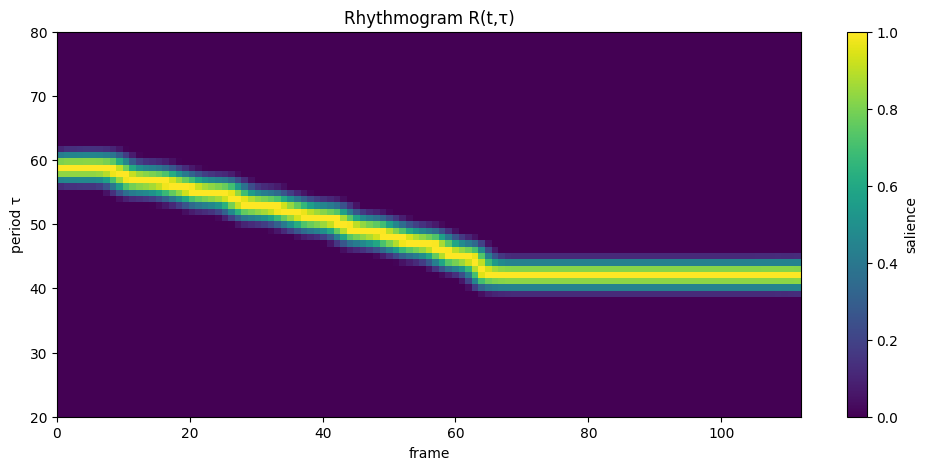

In [2]:
N=1800
x=np.zeros(N)
pos=30.0; period=60.0
while pos<N:
    x[int(round(pos))]=1
    if pos<1000: period=max(28.0,period-0.8)
    else: period=42.0
    pos+=period
x=gaussian_filter1d(x,1.2)
R,lags,starts=rhythmogram(x,frame_length=256,hop_length=16,lag_min=20,lag_max=80)
plt.figure(figsize=(12,5)); plt.imshow(R,origin='lower',aspect='auto',extent=[0,R.shape[1]-1,lags[0],lags[-1]]); plt.xlabel('frame'); plt.ylabel('period τ'); plt.title('Rhythmogram R(t,τ)'); plt.colorbar(label='salience'); plt.show()

## 2. From local candidates to a coherent path

Choosing the maximum independently in every frame can jump between competing ridges. Dynamic programming adds a transition cost that favors temporal continuity.

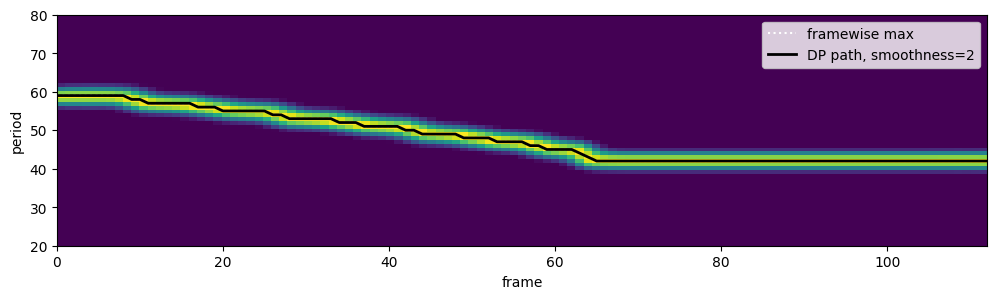

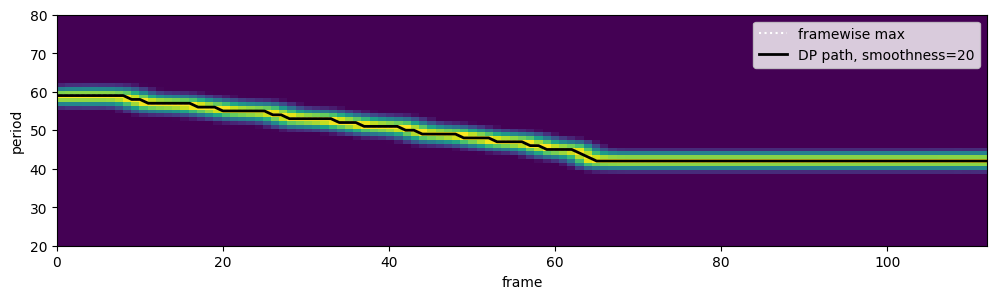

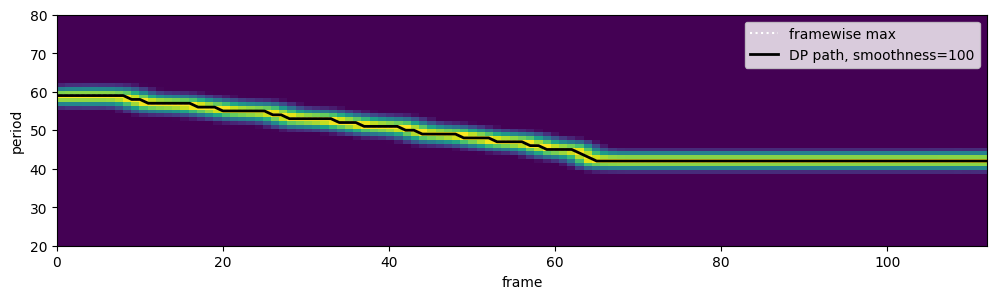

In [3]:
local=lags[np.argmax(R,axis=0)]
for s in [2,20,100]:
    path=dp_tempo_path(R,lags,smoothness=s)
    plt.figure(figsize=(12,3)); plt.imshow(R,origin='lower',aspect='auto',extent=[0,R.shape[1]-1,lags[0],lags[-1]]); plt.plot(np.arange(len(local)),local,'w:',label='framewise max'); plt.plot(np.arange(len(path)),path,'k-',lw=2,label=f'DP path, smoothness={s}'); plt.xlabel('frame'); plt.ylabel('period'); plt.legend(); plt.show()

## 3. What the smoothness parameter means

A small transition penalty follows rapid local changes but is vulnerable to spurious peaks. A large penalty produces a stable path but can lag behind genuine tempo changes. This is the modelling trade-off behind tempo-path estimation.